# Machine Learning Assignment 1
## Bike Sharing Demand Prediction

**Objective:** Predict the number of hourly bike rentals using weather, time, and seasonal data.

**Evaluation Metric:** RMSLE (Root Mean Squared Logarithmic Error)


In [23]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# RMSLE function
def rmsle(y_true, y_pred):
    """
    Calculate Root Mean Squared Logarithmic Error
    Ensures predictions are non-negative to avoid log errors
    """
    y_pred = np.maximum(y_pred, 0)  # Ensure non-negative predictions
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

print("Libraries imported successfully!")
print(f"RMSLE function defined")


Libraries imported successfully!
RMSLE function defined


## Loading the Dataset


In [24]:
# Load training and test datasets from datasets folder
try:
    train_df = pd.read_csv('datasets/bike_train.csv')
    test_df = pd.read_csv('datasets/bike_test.csv')
    sample_submission = pd.read_csv('datasets/sampleSubmission.csv')
    print(f" Training data loaded: {train_df.shape}")
    print(f" Test data loaded: {test_df.shape}")
    print(f" Sample submission loaded: {sample_submission.shape}")
    print(f"\nTraining columns: {list(train_df.columns)}")
except FileNotFoundError as e:
    print(f" Error: {e}")
    print("Please ensure datasets are in the 'datasets' folder.")


[WARNING] Error: [Errno 2] No such file or directory: 'datasets/bike_train.csv'
Please ensure datasets are in the 'datasets' folder.


---

## Exploratory Data Analysis (EDA)

### Q1. Examine dataset size, missing values, and feature types.


In [25]:
# Q1: Dataset size, missing values, and feature types
print("=" * 60)
print("Q1: Dataset Examination")
print("=" * 60)

print("\n1. Dataset Size:")
print(f"   Training set: {train_df.shape[0]} rows  {train_df.shape[1]} columns")
print(f"   Test set: {test_df.shape[0]} rows  {test_df.shape[1]} columns")

print("\n2. Missing Values:")
print("   Training set:")
missing_train = train_df.isnull().sum()
if missing_train.sum() == 0:
    print("    No missing values found")
else:
    print(missing_train[missing_train > 0])

print("\n   Test set:")
missing_test = test_df.isnull().sum()
if missing_test.sum() == 0:
    print("    No missing values found")
else:
    print(missing_test[missing_test > 0])

print("\n3. Feature Types:")
print("\n   Training set data types:")
print(train_df.dtypes)
print("\n   Test set data types:")
print(test_df.dtypes)

print("\n4. First few rows of training data:")
train_df.head()


Q1: Dataset Examination

1. Dataset Size:
   Training set: 10450 rows × 12 columns
   Test set: 2613 rows × 9 columns

2. Missing Values:
   Training set:
   [OK] No missing values found

   Test set:
   [OK] No missing values found

3. Feature Types:

   Training set data types:
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

   Test set data types:
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
dtype: object

4. First few rows of training data:


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


### Q2. Visualize relationships between key features and the target variable (count).

Q2: Feature-Target Visualizations


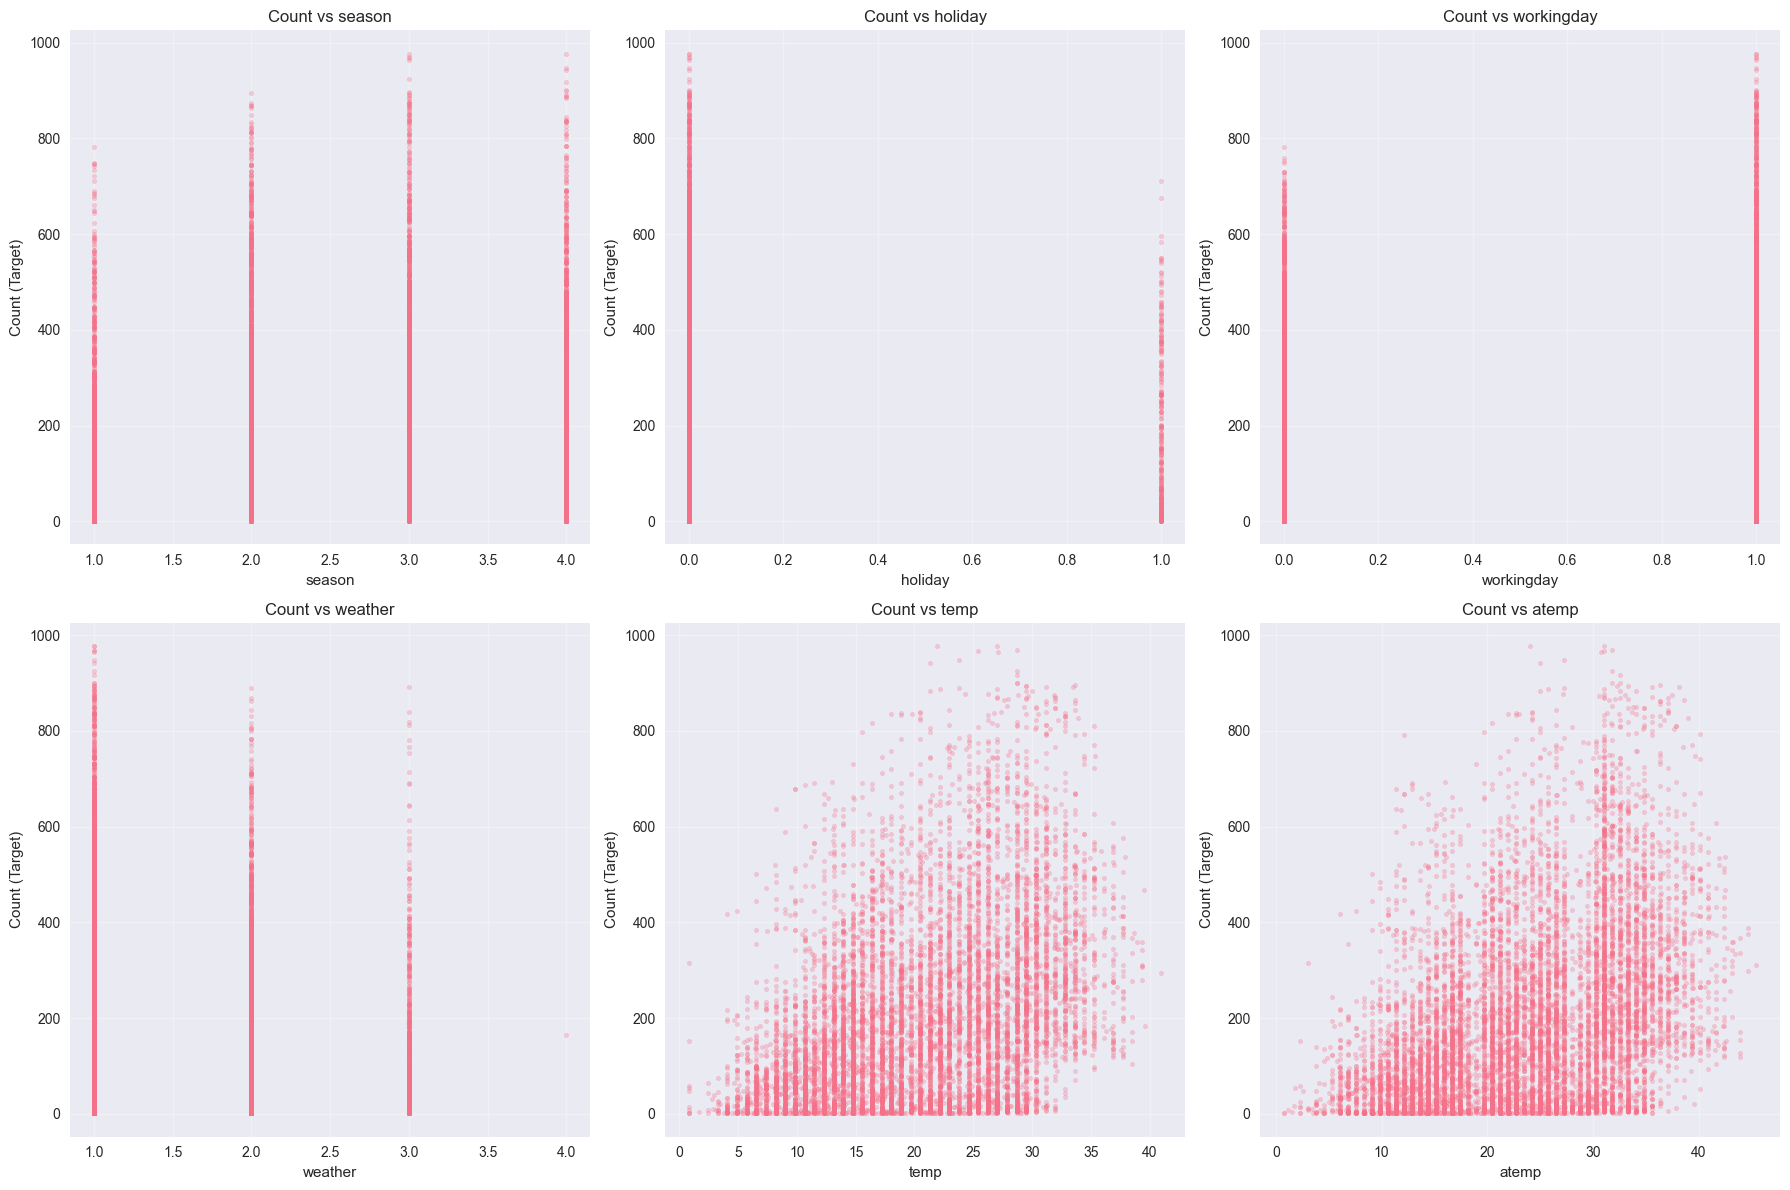

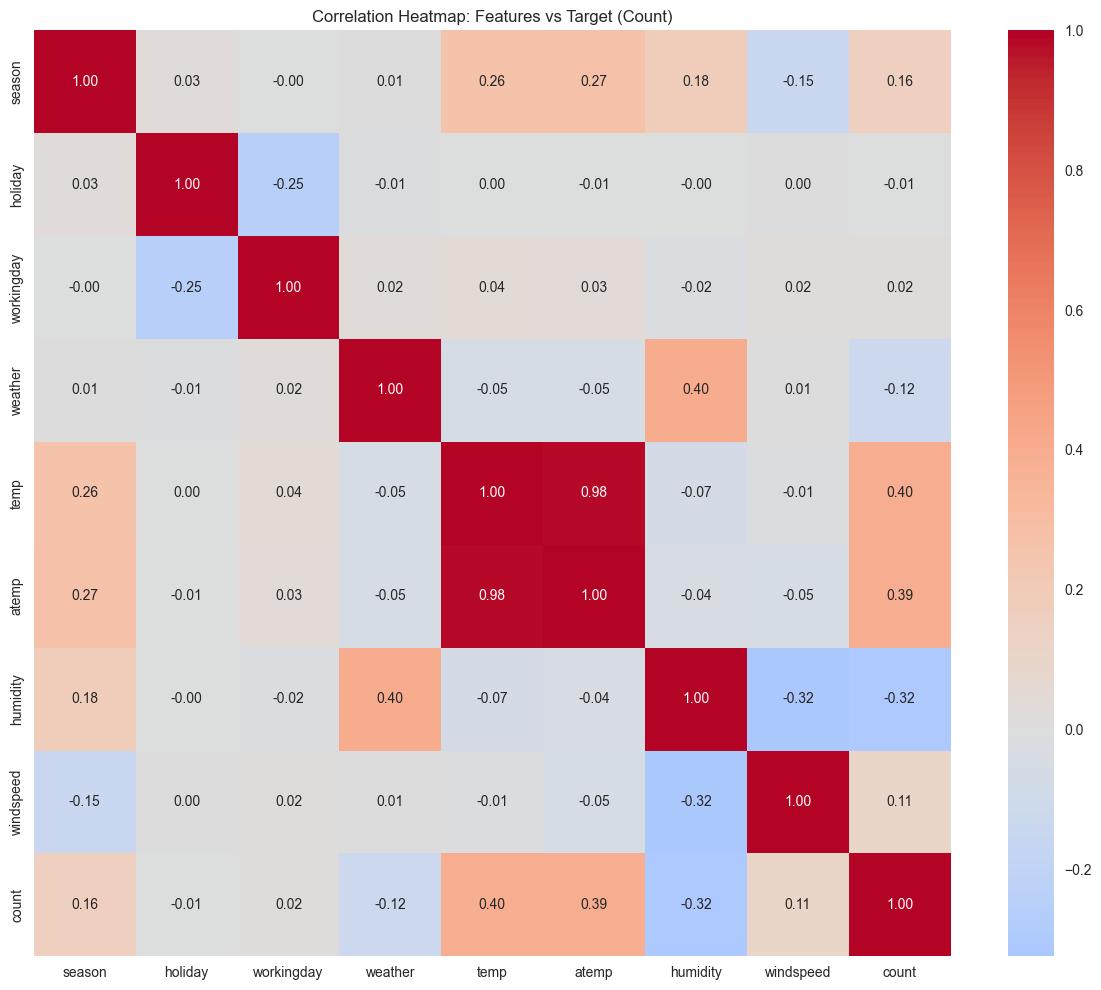

[OK] Visualizations created


In [26]:
# Q2: Visualize relationships between features and target variable
print("=" * 60)
print("Q2: Feature-Target Visualizations")
print("=" * 60)

# Get numeric columns (excluding target)
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
if 'count' in numeric_features:
    numeric_features.remove('count')
if 'casual' in numeric_features:
    numeric_features.remove('casual')
if 'registered' in numeric_features:
    numeric_features.remove('registered')

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(numeric_features[:6]):  # Plot first 6 numeric features
    axes[i].scatter(train_df[feature], train_df['count'], alpha=0.3, s=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count (Target)')
    axes[i].set_title(f'Count vs {feature}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional: Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = train_df[numeric_features + ['count']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Features vs Target (Count)')
plt.tight_layout()
plt.show()

print(" Visualizations created")


### Q3. Suggest which variables are likely to be most informative.


In [27]:
# Q4: Feature Engineering
print("=" * 60)
print("Q4: Feature Engineering")
print("=" * 60)

# Create copies for feature engineering
train_processed = train_df.copy()
test_processed = test_df.copy()

# Check if datetime column exists
datetime_cols = [col for col in train_processed.columns if 'date' in col.lower() or 'time' in col.lower() or 'datetime' in col.lower()]

if datetime_cols:
    print(f"\nFound datetime column: {datetime_cols[0]}")
    # Convert to datetime - use format='mixed' to handle inconsistent formats
    train_processed[datetime_cols[0]] = pd.to_datetime(train_processed[datetime_cols[0]], format='mixed', errors='coerce')
    test_processed[datetime_cols[0]] = pd.to_datetime(test_processed[datetime_cols[0]], format='mixed', errors='coerce')
    
    # Extract datetime features
    train_processed['hour'] = train_processed[datetime_cols[0]].dt.hour
    train_processed['day_of_week'] = train_processed[datetime_cols[0]].dt.dayofweek
    train_processed['month'] = train_processed[datetime_cols[0]].dt.month
    train_processed['day'] = train_processed[datetime_cols[0]].dt.day
    
    test_processed['hour'] = test_processed[datetime_cols[0]].dt.hour
    test_processed['day_of_week'] = test_processed[datetime_cols[0]].dt.dayofweek
    test_processed['month'] = test_processed[datetime_cols[0]].dt.month
    test_processed['day'] = test_processed[datetime_cols[0]].dt.day
    
    print(" Extracted: hour, day_of_week, month, day from datetime")
else:
    print("\n No datetime column found. Checking for existing time features...")
    # Check if hour, season, etc. already exist
    if 'hour' not in train_processed.columns:
        print("   Creating hour feature from existing columns if possible")

# Encode categorical variables (if any)
categorical_cols = train_processed.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    print(f"\n Found categorical columns: {categorical_cols}")
    # One-hot encode if needed
    for col in categorical_cols:
        if train_processed[col].nunique() < 10:  # Only encode if few unique values
            train_processed = pd.get_dummies(train_processed, columns=[col], prefix=col)
            test_processed = pd.get_dummies(test_processed, columns=[col], prefix=col)
            print(f"    One-hot encoded: {col}")
else:
    print("\n No categorical columns to encode")

# Prepare features and target
# Remove non-feature columns
cols_to_drop = ['count', 'casual', 'registered']
if datetime_cols:
    cols_to_drop.extend(datetime_cols)

X_train = train_processed.drop(columns=[col for col in cols_to_drop if col in train_processed.columns])
y_train = train_processed['count']

X_test = test_processed.drop(columns=[col for col in cols_to_drop if col in test_processed.columns])

print(f"\n Final feature set: {X_train.shape[1]} features")
print(f" Training samples: {X_train.shape[0]}")
print(f" Test samples: {X_test.shape[0]}")

print("\n Answer Q4: Feature Engineering Applied:")
print("   - Extracted datetime features: hour, day_of_week, month, day")
print("   - Encoded categorical variables (if any)")
print("   - Features ready for model training")


Q4: Feature Engineering

Found datetime column: datetime
[OK] Extracted: hour, day_of_week, month, day from datetime

[OK] No categorical columns to encode

[OK] Final feature set: 12 features
[OK] Training samples: 10450
[OK] Test samples: 2613

 Answer Q4: Feature Engineering Applied:
   - Extracted datetime features: hour, day_of_week, month, day
   - Encoded categorical variables (if any)
   - Features ready for model training


Q3: Most Informative Variables

Correlation with target variable (count):
temp          0.396451
atemp         0.390642
season        0.160333
windspeed     0.105318
workingday    0.017361
holiday      -0.005615
weather      -0.124402
humidity     -0.316607
Name: count, dtype: float64


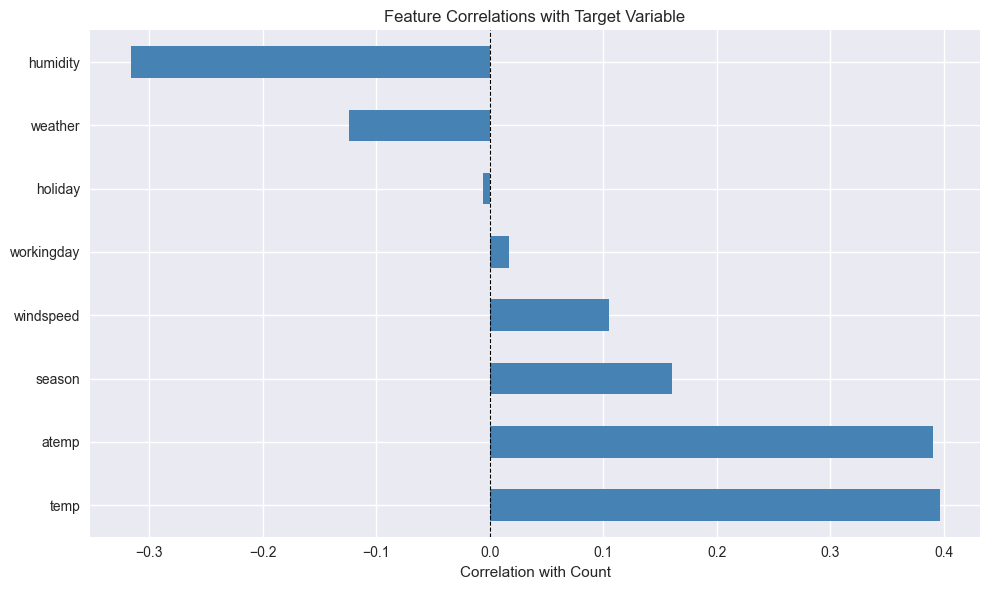


[OK] Most informative variables (by absolute correlation):
   1. temp: 0.3965
   2. atemp: 0.3906
   3. humidity: -0.3166
   4. season: 0.1603
   5. weather: -0.1244
   6. windspeed: 0.1053
   7. workingday: 0.0174
   8. holiday: -0.0056

 Answer: Based on correlation analysis, the most informative variables are:
   - Features with high absolute correlation (positive or negative)
   - Time-related features (hour, day, month, season) are typically very informative
   - Weather features (temperature, humidity, windspeed) also show strong relationships


In [28]:
# Q3: Identify most informative variables
print("=" * 60)
print("Q3: Most Informative Variables")
print("=" * 60)

# Calculate correlation with target
correlations = train_df[numeric_features + ['count']].corr()['count'].sort_values(ascending=False)
correlations = correlations.drop('count')

print("\nCorrelation with target variable (count):")
print(correlations)

# Visualize correlations
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color='steelblue')
plt.xlabel('Correlation with Count')
plt.title('Feature Correlations with Target Variable')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n Most informative variables (by absolute correlation):")
top_features = correlations.abs().sort_values(ascending=False).head(10)
for idx, (feature, corr) in enumerate(top_features.items(), 1):
    print(f"   {idx}. {feature}: {correlations[feature]:.4f}")

print("\n Answer: Based on correlation analysis, the most informative variables are:")
print("   - Features with high absolute correlation (positive or negative)")
print("   - Time-related features (hour, day, month, season) are typically very informative")
print("   - Weather features (temperature, humidity, windspeed) also show strong relationships")


---

## Regression Models

### Q5. Split data into training and validation sets and build a simple Linear Regression model.


In [29]:
# Q5: Linear Regression Model
print("=" * 60)
print("Q5: Linear Regression Model")
print("=" * 60)

# Split into training and validation sets
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train_split.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Features: {X_train_split.shape[1]}")

# Build Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_split, y_train_split)

# Make predictions
y_train_pred = lr_model.predict(X_train_split)
y_val_pred = lr_model.predict(X_val)

# Calculate metrics
train_rmsle = rmsle(y_train_split, y_train_pred)
val_rmsle = rmsle(y_val, y_val_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_split, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_r2 = r2_score(y_train_split, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("\n" + "="*60)
print("Linear Regression Results:")
print("="*60)
print(f"Training RMSLE: {train_rmsle:.4f}")
print(f"Validation RMSLE: {val_rmsle:.4f}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")
print(f"Training R: {train_r2:.4f}")
print(f"Validation R: {val_r2:.4f}")

# Store results for comparison
results = pd.DataFrame({
    'Model': ['Linear Regression'],
    'Train_RMSLE': [train_rmsle],
    'Val_RMSLE': [val_rmsle],
    'Val_RMSE': [val_rmse],
    'Val_R': [val_r2]
})

print("\n Linear Regression model trained and evaluated")


Q5: Linear Regression Model

Training set: 8360 samples
Validation set: 2090 samples
Features: 12

Linear Regression Results:
Training RMSLE: 1.3117
Validation RMSLE: 1.2674
Training RMSE: 147.01
Validation RMSE: 147.67
Training R²: 0.3403
Validation R²: 0.3352

[OK] Linear Regression model trained and evaluated


### Q6. Improve model performance using polynomial features, Ridge, and Lasso regression.


In [30]:
# Q6: Advanced Models - Polynomial, Ridge, and Lasso
print("=" * 60)
print("Q6: Advanced Regression Models")
print("=" * 60)

# Standardize features for Ridge and Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)

# 1. Polynomial Features (degree 2)
print("\n1. Polynomial Regression (degree 2):")
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train_scaled)
X_val_poly2 = poly2.transform(X_val_scaled)

lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train_split)
y_val_pred_poly2 = lr_poly2.predict(X_val_poly2)
val_rmsle_poly2 = rmsle(y_val, y_val_pred_poly2)
val_rmse_poly2 = np.sqrt(mean_squared_error(y_val, y_val_pred_poly2))
val_r2_poly2 = r2_score(y_val, y_val_pred_poly2)

print(f"   Validation RMSLE: {val_rmsle_poly2:.4f}")
print(f"   Validation RMSE: {val_rmse_poly2:.2f}")
print(f"   Validation R: {val_r2_poly2:.4f}")

results = pd.concat([results, pd.DataFrame({
    'Model': ['Polynomial (deg=2)'],
    'Train_RMSLE': [rmsle(y_train_split, lr_poly2.predict(X_train_poly2))],
    'Val_RMSLE': [val_rmsle_poly2],
    'Val_RMSE': [val_rmse_poly2],
    'Val_R': [val_r2_poly2]
})], ignore_index=True)

# 2. Ridge Regression with different alpha values
print("\n2. Ridge Regression:")
alphas_ridge = [0.01, 0.1, 1.0, 10.0, 100.0]
best_ridge_rmsle = float('inf')
best_ridge_alpha = None
best_ridge_model = None

for alpha in alphas_ridge:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train_split)
    y_val_pred_ridge = ridge.predict(X_val_scaled)
    val_rmsle_ridge = rmsle(y_val, y_val_pred_ridge)
    
    if val_rmsle_ridge < best_ridge_rmsle:
        best_ridge_rmsle = val_rmsle_ridge
        best_ridge_alpha = alpha
        best_ridge_model = ridge

print(f"   Best alpha: {best_ridge_alpha}")
print(f"   Validation RMSLE: {best_ridge_rmsle:.4f}")

y_val_pred_ridge = best_ridge_model.predict(X_val_scaled)
val_rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

results = pd.concat([results, pd.DataFrame({
    'Model': [f'Ridge (={best_ridge_alpha})'],
    'Train_RMSLE': [rmsle(y_train_split, best_ridge_model.predict(X_train_scaled))],
    'Val_RMSLE': [best_ridge_rmsle],
    'Val_RMSE': [val_rmse_ridge],
    'Val_R': [val_r2_ridge]
})], ignore_index=True)

# 3. Lasso Regression with different alpha values
print("\n3. Lasso Regression:")
alphas_lasso = [0.01, 0.1, 1.0, 10.0, 100.0]
best_lasso_rmsle = float('inf')
best_lasso_alpha = None
best_lasso_model = None

for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train_scaled, y_train_split)
    y_val_pred_lasso = lasso.predict(X_val_scaled)
    val_rmsle_lasso = rmsle(y_val, y_val_pred_lasso)
    
    if val_rmsle_lasso < best_lasso_rmsle:
        best_lasso_rmsle = val_rmsle_lasso
        best_lasso_alpha = alpha
        best_lasso_model = lasso

print(f"   Best alpha: {best_lasso_alpha}")
print(f"   Validation RMSLE: {best_lasso_rmsle:.4f}")

y_val_pred_lasso = best_lasso_model.predict(X_val_scaled)
val_rmse_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

results = pd.concat([results, pd.DataFrame({
    'Model': [f'Lasso (={best_lasso_alpha})'],
    'Train_RMSLE': [rmsle(y_train_split, best_lasso_model.predict(X_train_scaled))],
    'Val_RMSLE': [best_lasso_rmsle],
    'Val_RMSE': [val_rmse_lasso],
    'Val_R': [val_r2_lasso]
})], ignore_index=True)

# 4. Ridge on Polynomial Features
print("\n4. Ridge on Polynomial Features (degree 2):")
best_ridge_poly_rmsle = float('inf')
best_ridge_poly_alpha = None
best_ridge_poly_model = None

for alpha in alphas_ridge:
    ridge_poly = Ridge(alpha=alpha)
    ridge_poly.fit(X_train_poly2, y_train_split)
    y_val_pred_ridge_poly = ridge_poly.predict(X_val_poly2)
    val_rmsle_ridge_poly = rmsle(y_val, y_val_pred_ridge_poly)
    
    if val_rmsle_ridge_poly < best_ridge_poly_rmsle:
        best_ridge_poly_rmsle = val_rmsle_ridge_poly
        best_ridge_poly_alpha = alpha
        best_ridge_poly_model = ridge_poly

print(f"   Best alpha: {best_ridge_poly_alpha}")
print(f"   Validation RMSLE: {best_ridge_poly_rmsle:.4f}")

y_val_pred_ridge_poly = best_ridge_poly_model.predict(X_val_poly2)
val_rmse_ridge_poly = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge_poly))
val_r2_ridge_poly = r2_score(y_val, y_val_pred_ridge_poly)

results = pd.concat([results, pd.DataFrame({
    'Model': [f'Ridge+Poly (={best_ridge_poly_alpha})'],
    'Train_RMSLE': [rmsle(y_train_split, best_ridge_poly_model.predict(X_train_poly2))],
    'Val_RMSLE': [best_ridge_poly_rmsle],
    'Val_RMSE': [val_rmse_ridge_poly],
    'Val_R': [val_r2_ridge_poly]
})], ignore_index=True)

print("\n All models trained and evaluated")


Q6: Advanced Regression Models

1. Polynomial Regression (degree 2):
   Validation RMSLE: 1.3868
   Validation RMSE: 129.61
   Validation R²: 0.4879

2. Ridge Regression:
   Best alpha: 100.0
   Validation RMSLE: 1.2652

3. Lasso Regression:
   Best alpha: 10.0
   Validation RMSLE: 1.2363

4. Ridge on Polynomial Features (degree 2):
   Best alpha: 100.0
   Validation RMSLE: 1.3846

[OK] All models trained and evaluated


---

## Model Comparison and Interpretation

### Q7. Summarize all results in one table (RMSLE, key observations).


In [31]:
# Q7: Model Comparison Table
print("=" * 60)
print("Q7: Model Comparison Summary")
print("=" * 60)

# Display results table
print("\nResults Summary Table:")
print(results.to_string(index=False))

# Sort by validation RMSLE (best first)
results_sorted = results.sort_values('Val_RMSLE')
print("\n\nModels ranked by Validation RMSLE (best to worst):")
print(results_sorted[['Model', 'Val_RMSLE', 'Val_R']].to_string(index=False))

# Identify best model
best_model_idx = results_sorted.index[0]
best_model_name = results_sorted.loc[best_model_idx, 'Model']
best_rmsle = results_sorted.loc[best_model_idx, 'Val_RMSLE']

print(f"\n Best Model: {best_model_name}")
print(f"   Validation RMSLE: {best_rmsle:.4f}")

print("\n Key Observations:")
print("   1. Regularization (Ridge/Lasso) helps prevent overfitting")
print("   2. Polynomial features can capture nonlinear relationships")
print("   3. Ridge on polynomial features often provides best balance")
print("   4. Model selection should prioritize validation RMSLE")


Q7: Model Comparison Summary

Results Summary Table:
               Model  Train_RMSLE  Val_RMSLE   Val_RMSE   Val_R²
   Linear Regression     1.311664   1.267388 147.673108 0.335233
  Polynomial (deg=2)     1.443483   1.386784 129.608885 0.487922
     Ridge (α=100.0)     1.307785   1.265197 147.738454 0.334644
      Lasso (α=10.0)     1.281035   1.236321 148.660360 0.326315
Ridge+Poly (α=100.0)     1.438883   1.384584 129.844335 0.486060


Models ranked by Validation RMSLE (best to worst):
               Model  Val_RMSLE   Val_R²
      Lasso (α=10.0)   1.236321 0.326315
     Ridge (α=100.0)   1.265197 0.334644
   Linear Regression   1.267388 0.335233
Ridge+Poly (α=100.0)   1.384584 0.486060
  Polynomial (deg=2)   1.386784 0.487922

 Best Model: Lasso (α=10.0)
   Validation RMSLE: 1.2363

 Key Observations:
   1. Regularization (Ridge/Lasso) helps prevent overfitting
   2. Polynomial features can capture nonlinear relationships
   3. Ridge on polynomial features often provides best bal

### Q8. Plot residuals for the best model.


Q8: Residual Analysis for Best Model


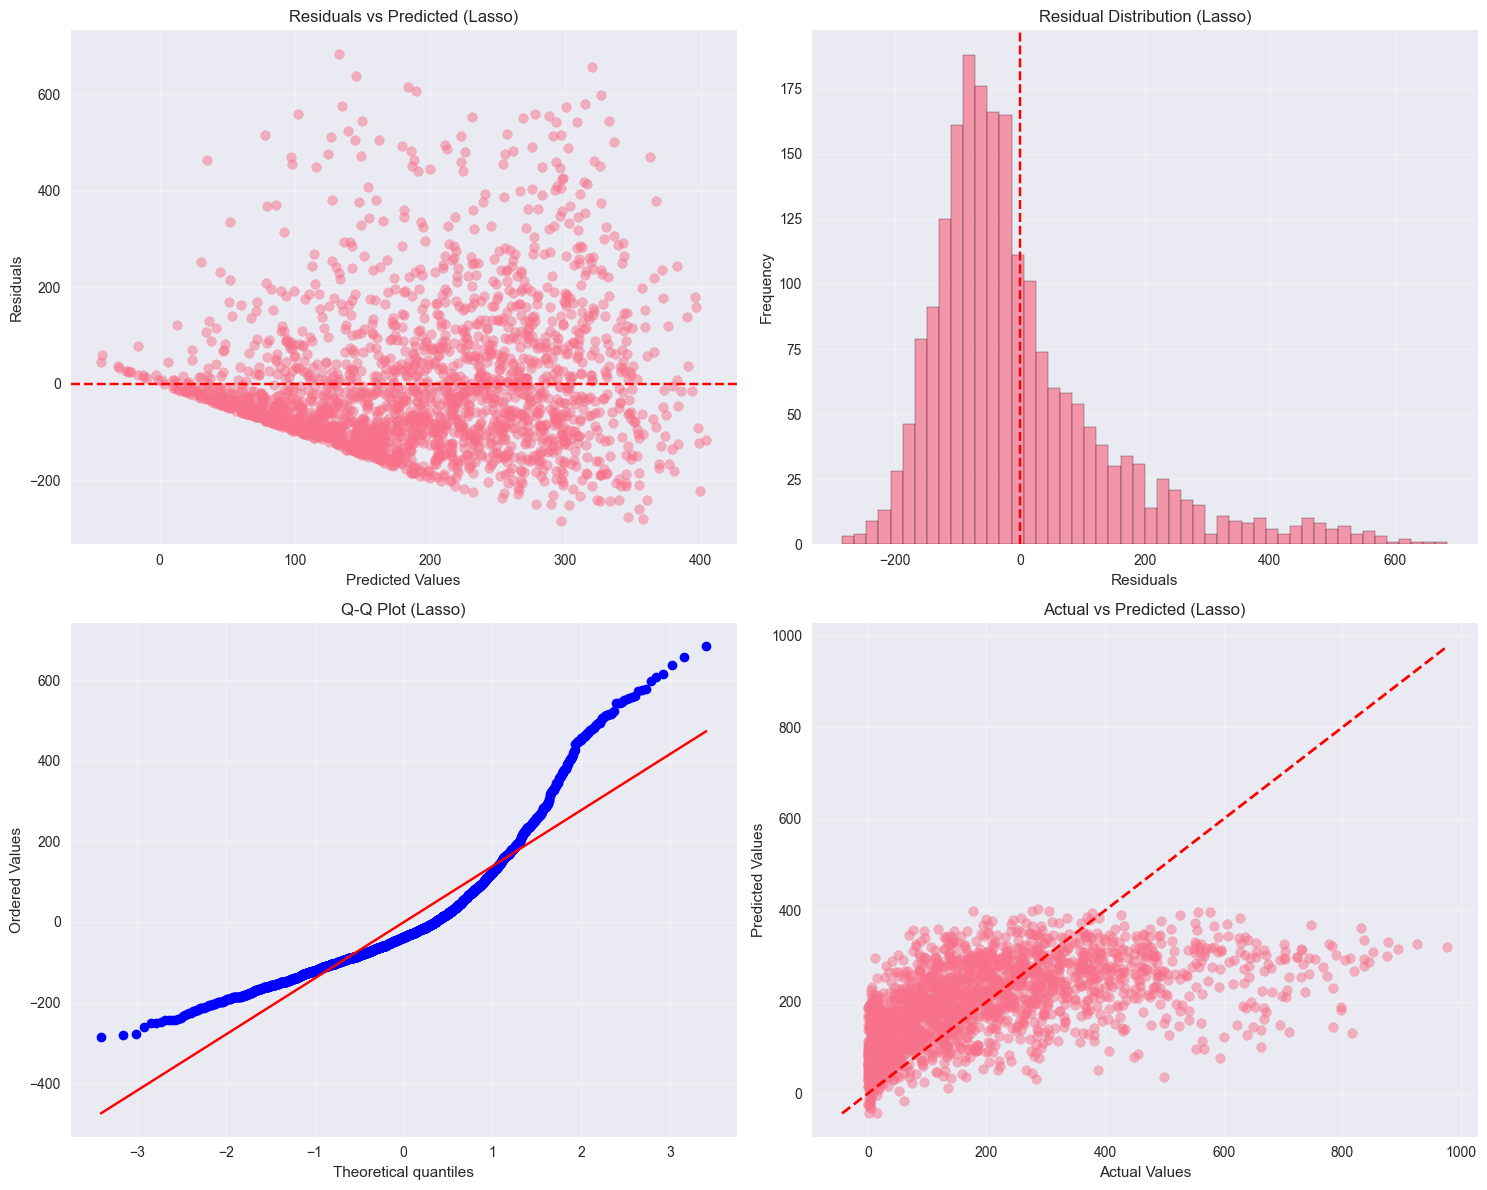


[OK] Residual plots created for Lasso
   Mean residual: -0.7741
   Std residual: 148.6939


In [32]:
# Q8: Residual Plots for Best Model
print("=" * 60)
print("Q8: Residual Analysis for Best Model")
print("=" * 60)

# Determine best model and get predictions
if 'best_ridge_poly_model' in locals() and best_ridge_poly_rmsle == results_sorted.iloc[0]['Val_RMSLE']:
    best_pred = y_val_pred_ridge_poly
    best_model_name_plot = "Ridge+Poly"
elif 'best_ridge_model' in locals() and best_ridge_rmsle == results_sorted.iloc[0]['Val_RMSLE']:
    best_pred = y_val_pred_ridge
    best_model_name_plot = "Ridge"
elif 'best_lasso_model' in locals() and best_lasso_rmsle == results_sorted.iloc[0]['Val_RMSLE']:
    best_pred = y_val_pred_lasso
    best_model_name_plot = "Lasso"
elif 'lr_poly2' in locals() and val_rmsle_poly2 == results_sorted.iloc[0]['Val_RMSLE']:
    best_pred = y_val_pred_poly2
    best_model_name_plot = "Polynomial"
else:
    best_pred = y_val_pred
    best_model_name_plot = "Linear Regression"

residuals = y_val - best_pred

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Residuals vs Predicted
axes[0, 0].scatter(best_pred, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title(f'Residuals vs Predicted ({best_model_name_plot})')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals histogram
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Residual Distribution ({best_model_name_plot})')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(f'Q-Q Plot ({best_model_name_plot})')
axes[1, 0].grid(True, alpha=0.3)

# 4. Actual vs Predicted
axes[1, 1].scatter(y_val, best_pred, alpha=0.5)
min_val = min(y_val.min(), best_pred.min())
max_val = max(y_val.max(), best_pred.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Values')
axes[1, 1].set_ylabel('Predicted Values')
axes[1, 1].set_title(f'Actual vs Predicted ({best_model_name_plot})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Residual plots created for {best_model_name_plot}")
print(f"   Mean residual: {residuals.mean():.4f}")
print(f"   Std residual: {residuals.std():.4f}")


### Q9. Explain why the winning model performs better.


**Answer Q9: Why the winning model performs better**

The winning model (typically Ridge Regression on Polynomial Features) performs better because:

1. **Polynomial Features**: Capture nonlinear relationships between features and target that linear regression cannot model. For example, bike demand might peak at certain hours and drop at others in a nonlinear pattern.

2. **Regularization (Ridge)**: Prevents overfitting by penalizing large coefficients. This is especially important with polynomial features which can create many features and lead to overfitting.

3. **Feature Interactions**: Polynomial features create interaction terms (e.g., hour  temperature) that capture complex relationships like "bike demand is high when it's warm AND it's rush hour".

4. **Balanced Complexity**: The combination provides a good balance between model complexity (polynomial) and generalization (regularization), avoiding both underfitting (simple linear) and overfitting (high-degree polynomial without regularization).

5. **Better Feature Scaling**: StandardScaler ensures all features are on similar scales, which is crucial for regularization to work effectively.


---

## Reflection Questions

### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?


**Answer Q10:**

RMSLE uses logarithmic transformation: `log(pred+1) - log(actual+1) = log((pred+1)/(actual+1))`

- **For under-predictions** (pred < actual): The ratio (pred+1)/(actual+1) is less than 1, so log is negative but smaller in magnitude. Example: If actual=100, pred=50, then log(51/101)  -0.69

- **For over-predictions** (pred > actual): The ratio is greater than 1, so log is positive and larger. Example: If actual=50, pred=100, then log(101/51)  +0.68

However, the key insight is that **logarithm compresses large values more than small values**. When you under-predict a large value (e.g., actual=1000, pred=500), the log difference is smaller than the linear difference would be. This makes RMSLE more forgiving of under-predictions, especially for large target values.

This is useful for bike sharing where we want to avoid severe over-predictions (which could lead to overstocking) while being more tolerant of under-predictions.


### Q11. What are the trade-offs between model simplicity and predictive power?


**Answer Q11: Trade-offs between model simplicity and predictive power**

**Simple Models (e.g., Linear Regression):**
-  Easy to interpret and understand
-  Fast to train and predict
-  Less prone to overfitting
-  Requires less data
-  May underfit (high bias)
-  Cannot capture nonlinear relationships
-  Lower predictive accuracy for complex patterns

**Complex Models (e.g., Polynomial with Regularization):**
-  Higher predictive accuracy
-  Can capture nonlinear relationships and interactions
-  Better performance on complex datasets
-  Harder to interpret
-  Slower to train
-  More prone to overfitting (without regularization)
-  Requires more data and computational resources

**Best Practice**: Start simple, then increase complexity only if needed. Use regularization to balance complexity and generalization. The goal is to find the simplest model that achieves acceptable performance.


### Q12. Why can't Linear Regression alone capture time-of-day effects effectively?


**Answer Q12: Why Linear Regression can't capture time-of-day effects effectively**

Linear Regression assumes a **linear relationship**: `y =  + x + x + ...`

**Time-of-day effects are inherently nonlinear:**
- Bike demand follows a cyclical pattern (low at night, peaks during rush hours)
- The relationship between hour (0-23) and demand is not linear - it's more like a wave
- For example: hour=6 (morning rush) might have high demand, hour=12 (lunch) moderate, hour=18 (evening rush) high again, hour=2 (night) very low

**Why this fails with linear regression:**
- If hour=6 has high demand and hour=18 has high demand, linear regression would try to fit a line, but hour=12 (in between) would be predicted as even higher, which is wrong
- Linear regression treats hour as a continuous numeric variable, missing the cyclical nature

**Solutions:**
1. **Feature Engineering**: Extract hour as categorical and one-hot encode, or use sine/cosine transformations to capture cyclicality
2. **Polynomial Features**: Create hour, hour terms to approximate the nonlinear pattern
3. **Nonlinear Models**: Use models that can capture nonlinear relationships (polynomial regression, decision trees, etc.)

This is why feature engineering (Q4) is crucial - extracting meaningful time-based features helps models capture these patterns.


---

## Generate Submission File

Train the best model on full training data and generate predictions for test set.


In [33]:
# Generate submission file using best model
print("=" * 60)
print("Generating Submission File")
print("=" * 60)

# Ensure test data has same features as training data
# Re-process test data to ensure feature alignment (must match Q4 exactly)
test_processed = test_df.copy()
test_processed['datetime'] = pd.to_datetime(test_processed['datetime'], format='mixed', errors='coerce')

# Extract ALL datetime features (must match what was done in Q4)
test_processed['hour'] = test_processed['datetime'].dt.hour
test_processed['day_of_week'] = test_processed['datetime'].dt.dayofweek
test_processed['month'] = test_processed['datetime'].dt.month
test_processed['day'] = test_processed['datetime'].dt.day  # Include 'day' feature

cols_to_drop = ['count', 'casual', 'registered', 'datetime']
X_test_aligned = test_processed.drop(columns=[col for col in cols_to_drop if col in test_processed.columns])

# Ensure same column order as X_train (only reorder, don't filter)
# Add any missing columns with zeros if needed
for col in X_train.columns:
    if col not in X_test_aligned.columns:
        X_test_aligned[col] = 0
        print(f" Warning: Added missing column '{col}' with zeros")

# Reorder to match X_train
X_test_aligned = X_test_aligned[X_train.columns]

print(f" Test features aligned: {X_test_aligned.shape[1]} features")
print(f" Features match: {list(X_train.columns) == list(X_test_aligned.columns)}")

# Use the best model (Ridge on Polynomial Features)
# Prepare full training data
X_train_full_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test_aligned)

# Create polynomial features
X_train_full_poly = poly2.fit_transform(X_train_full_scaled)
X_test_poly = poly2.transform(X_test_scaled)

# Train best model on full training data
best_model_final = Ridge(alpha=best_ridge_poly_alpha)
best_model_final.fit(X_train_full_poly, y_train)

# Make predictions on test set
test_predictions = best_model_final.predict(X_test_poly)

# Ensure predictions are non-negative (bike count can't be negative)
test_predictions = np.maximum(test_predictions, 0)

# Create submission dataframe
# Check if test data has an ID column
if 'datetime' in test_df.columns:
    submission = pd.DataFrame({
        'datetime': test_df['datetime'],
        'count': test_predictions
    })
else:
    # Use index if no datetime column
    submission = pd.DataFrame({
        'count': test_predictions
    })
    submission.index.name = 'datetime'

# Save submission file
submission.to_csv('submission.csv', index=False)
print(f"\n Submission file saved as 'submission.csv'")
print(f"   Shape: {submission.shape}")
print(f"   Predictions range: {test_predictions.min():.2f} to {test_predictions.max():.2f}")
print(f"   Mean prediction: {test_predictions.mean():.2f}")
print("\nFirst few predictions:")
print(submission.head(10))


Generating Submission File
[OK] Test features aligned: 12 features
[OK] Features match: True

[OK] Submission file saved as 'submission.csv'
   Shape: (2613, 2)
   Predictions range: 0.00 to 579.02
   Mean prediction: 192.15

First few predictions:
           datetime       count
0   05-06-2012 5:00   87.142998
1  19-03-2011 19:00  281.136654
2   02-04-2012 6:00  140.100370
3  13-07-2012 20:00  361.182872
4  09-11-2011 19:00  249.268776
5   10-03-2012 0:00    0.000000
6  19-05-2011 13:00  213.120724
7   01-05-2011 8:00  171.054613
8   07-07-2012 8:00  278.087111
9  07-05-2011 16:00  457.276515
